### Import libraries

In [211]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import calendar

import warnings
warnings.filterwarnings('ignore')

### import data

In [212]:
df = pd.read_csv("hotel_bookings.csv", sep=',', skipinitialspace=True)
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


### General Overview & Cleaning

In [213]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [214]:
df.shape

(119390, 32)

In [215]:
# Count missing values for each column
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [216]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1. Explore each column 

In [218]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- hotel ---
City Hotel      79330
Resort Hotel    40060
Name: hotel, dtype: int64

--- is_canceled ---
0    75166
1    44224
Name: is_canceled, dtype: int64

--- lead_time ---
0      6345
1      3460
2      2069
3      1816
4      1715
       ... 
400       1
370       1
532       1
371       1
463       1
Name: lead_time, Length: 479, dtype: int64

--- arrival_date_year ---
2016    56707
2017    40687
2015    21996
Name: arrival_date_year, dtype: int64

--- arrival_date_month ---
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: arrival_date_month, dtype: int64

--- arrival_date_week_number ---
33    3580
30    3087
32    3045
34    3040
18    2926
21    2854
28    2853
17    2805
20    2785
29    2763
42    2756
31    2741
41    2699
15    2689
27    2664
25    2663
38    2661
23    2621
35    2593
3

In [219]:
df = df.drop(columns=[
    'reservation_status',
    'reservation_status_date'
])

Reason: they encode the future.
#### target = 'is_canceled'

In [220]:
# agent is an identifier, not a quantity
df['has_agent'] = df['agent'].notna().astype(int)
df = df.drop(columns=['agent'])

In [221]:
# arrival_date is a temporary helper column, not a final feature

import calendar

# Convert month names to numbers safely
df['arrival_month_num'] = df['arrival_date_month'].map(
    {month: i for i, month in enumerate(calendar.month_name) if month}
)

df['arrival_date'] = pd.to_datetime(
    dict(
        year=df['arrival_date_year'],
        month=df['arrival_month_num'],
        day=df['arrival_date_day_of_month']
    ),
    errors='coerce'
)

In [222]:
# Feature extraction
df['arrival_month'] = df['arrival_date'].dt.month
df['arrival_weekday'] = df['arrival_date'].dt.weekday
df['arrival_week'] = df['arrival_date'].dt.isocalendar().week.astype(int)

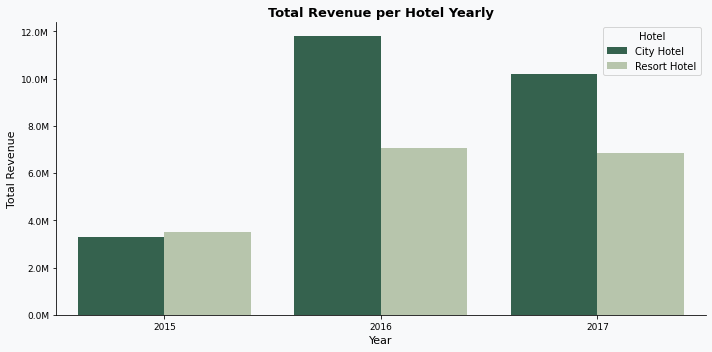

In [223]:
# ============================================================
# 3.  TOTAL REVENUE PER HOTEL YEARLY  (bar)
# ============================================================
df['total_revenue'] = df['adr'] * (df['stays_in_weekend_nights'] + df['stays_in_week_nights'])

rev_year = (df.groupby(['arrival_date_year', 'hotel'])['total_revenue']
              .sum().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=rev_year, x='arrival_date_year', y='total_revenue',
            hue='hotel', palette=['#2D6A4F', '#B7C9A8'], ax=ax)
ax.set_title('Total Revenue per Hotel Yearly')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Hotel')
plt.tight_layout()
plt.show()

In [90]:
# Drop redundant columns
df.drop(
    columns=[
        'arrival_date',
        'arrival_month_num',
        'arrival_date_year',
        'arrival_date_month',
        'arrival_date_day_of_month'
    ],
    inplace=True
)

arrival_date = 2016-07-15

- arrival_month = 7      (Extracts just the month number)
- arrival_weekday = 4    (Extracts day of the week: Monday = 0, Sunday = 6)
- arrival_week = 28      (Extracts week number in the year (1–52))

We dropped year because the dataset spans only three years and shows no long-term trend, while seasonality and weekday effects are more informative for modeling booking behavior

#### 4️⃣ Why month / weekday / week are more useful

These capture behavioral patterns:

arrival_month

- Seasonality (summer vs winter)

- Holiday periods

- High-demand months

arrival_weekday

- Weekend vs weekday behavior

- Business vs leisure bookings

arrival_week

- Peak travel weeks

- School holidays

- Event-driven demand

📌 These directly affect cancellation behavior.

In [91]:
# Convert categorical columns
categorical_cols = [
    "hotel","meal","market_segment","distribution_channel",
    "reserved_room_type","assigned_room_type","deposit_type",
    "customer_type","country"
]
df[categorical_cols] = df[categorical_cols].astype("category")

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119390 non-null  category
 1   is_canceled                     119390 non-null  int64   
 2   lead_time                       119390 non-null  int64   
 3   arrival_date_week_number        119390 non-null  int64   
 4   stays_in_weekend_nights         119390 non-null  int64   
 5   stays_in_week_nights            119390 non-null  int64   
 6   adults                          119390 non-null  int64   
 7   children                        119386 non-null  float64 
 8   babies                          119390 non-null  int64   
 9   meal                            119390 non-null  category
 10  country                         118902 non-null  category
 11  market_segment                  119390 non-null  category
 12  di

### 2. Handling Duplicates

In [93]:
num_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", num_duplicates)

Number of duplicated rows: 32265


In [94]:
# Before removing duplicates
print("Duplicates before:", df.duplicated().sum())

# Optional: view the duplicate rows
display(df[df.duplicated()].head())

Duplicates before: 32265


,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_agent,arrival_month,arrival_weekday,arrival_week
5,Resort Hotel,0,14,27,0,2,2,0.0,0,BB,...,NaN,0,Transient,98.00,0,1,1,7,2,27
22,Resort Hotel,0,72,27,2,4,2,0.0,0,BB,...,NaN,0,Transient,84.67,0,1,1,7,2,27
43,Resort Hotel,0,70,27,2,3,2,0.0,0,HB,...,NaN,0,Transient,137.00,0,1,1,7,3,27
138,Resort Hotel,1,5,28,1,0,2,0.0,0,BB,...,NaN,0,Transient,97.00,0,0,1,7,6,27
200,Resort Hotel,0,0,28,0,1,1,0.0,0,BB,...,NaN,0,Transient,109.80,0,3,1,7,1,28


In [95]:
# Remove duplicates
df = df.drop_duplicates()

# After removing duplicates
print("Duplicates after:", df.duplicated().sum())

Duplicates after: 0


In [96]:
df.shape

(87125, 30)

### 3. Handle missing values

In [97]:
df.isnull().sum().sort_values(ascending=False)

company                           81877
country                             451
children                              4
hotel                                 0
reserved_room_type                    0
arrival_weekday                       0
arrival_month                         0
has_agent                             0
total_of_special_requests             0
required_car_parking_spaces           0
adr                                   0
customer_type                         0
days_in_waiting_list                  0
deposit_type                          0
booking_changes                       0
assigned_room_type                    0
previous_bookings_not_canceled        0
is_canceled                           0
previous_cancellations                0
is_repeated_guest                     0
distribution_channel                  0
market_segment                        0
meal                                  0
babies                                0
adults                                0


| Column       | Missing %    | Notes                                          |
| ------------ | ------------ | ---------------------------------------------- |
| **company**  | ~94%         | Too many missing → drop column                 |
| **country**  | ~452 missing | ~0.5% → fill with MODE (“PRT”)                 |
| **children** | 4 missing    | Tiny amount → fill with median or 0            |
| Others       | 0%           | Good                                           |


In [98]:
# Check percentage of missing values in 'company' column
(df['company'].isnull().sum()) / (df['company'].shape[0]) * 100  

93.9764705882353

In [99]:
# ~94.3% null → too many missing values → drop column
df.drop(columns = ['company'], inplace = True)

In [100]:
# Check percentage of missing values in 'country'
(df['country'].isnull().sum()) / (df['country'].shape[0]) * 100       

0.5176470588235295

In [101]:
# Only 0.5% null → fill with most frequent value
df['country'].fillna(df['country'].mode()[0], inplace = True)

In [102]:
# drop NaN rows in children column
df = df.dropna(subset=['children'])

In [103]:
# Final check for missing values
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_week_number          0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
has_agent                         0
arrival_month                     0
arrival_weekday             

In [104]:
# Set thresholds
row_count = len(df)
drop_threshold = 0.3  # drop columns with >30% missing

In [105]:
# 1. Drop columns with too many missing values
missing_ratios = df.isnull().mean()
cols_to_drop = missing_ratios[missing_ratios > drop_threshold].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")

Dropped columns: []


In [106]:
df.shape

(87121, 29)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 87121 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87121 non-null  category
 1   is_canceled                     87121 non-null  int64   
 2   lead_time                       87121 non-null  int64   
 3   arrival_date_week_number        87121 non-null  int64   
 4   stays_in_weekend_nights         87121 non-null  int64   
 5   stays_in_week_nights            87121 non-null  int64   
 6   adults                          87121 non-null  int64   
 7   children                        87121 non-null  float64 
 8   babies                          87121 non-null  int64   
 9   meal                            87121 non-null  category
 10  country                         87121 non-null  category
 11  market_segment                  87121 non-null  category
 12  distribution_chan

### 4. Handling Outliers (Domain-based cleaning)

- Numeric columns only
- (Categorical columns NEVER get outlier treatment)

In [108]:
numeric_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

### Outlier philosophy per column
We will:

- Classify columns

- Decide KEEP / CAP / TRANSFORM / REMOVE

- Do it model-aware

🟢 Columns where “extreme” values are REAL behavior

👉 DO NOT REMOVE

✔ Keep as-is (maybe cap later)



| Column                           | Why                                |
| -------------------------------- | ---------------------------------- |
| `lead_time`                      | People really book 300+ days ahead |
| `adr`                            | Luxury / suite bookings            |
| `days_in_waiting_list`           | Operational bottlenecks            |
| `previous_cancellations`         | Chronic cancelers                  |
| `previous_bookings_not_canceled` | Loyal customers                    |


🟡 Columns where extreme values are suspicious

👉 CAP (Winsorize)

| Column                    | Reason                                |
| ------------------------- | ------------------------------------- |
| `stays_in_weekend_nights` | Someone staying 50 weekends? unlikely |
| `stays_in_week_nights`    | Same logic                            |
| `adults`                  | >4 usually data error                 |
| `children`                | Extreme values rare                   |
| `babies`                  | >2 very unlikely                      |


🔴 Columns where extreme values are almost always errors

👉 REMOVE rows

| Column                        | Why                  |
| ----------------------------- | -------------------- |
| `required_car_parking_spaces` | 10+ makes no sense   |
| `total_of_special_requests`   | Usually capped (0–5) |

🔹 Step 1 — Visualize key numerical features

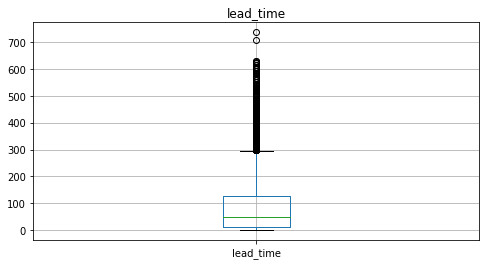

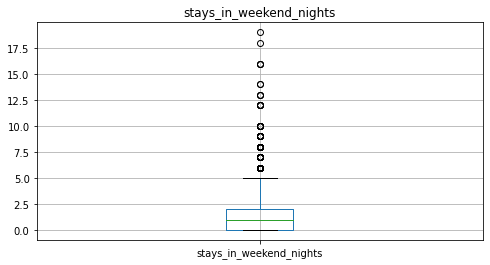

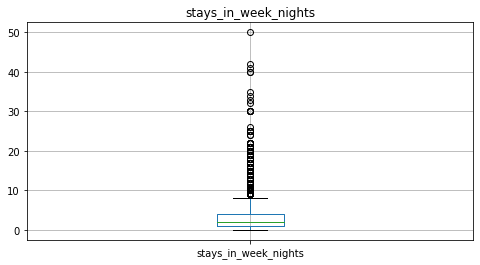

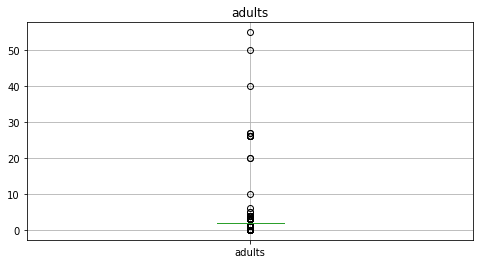

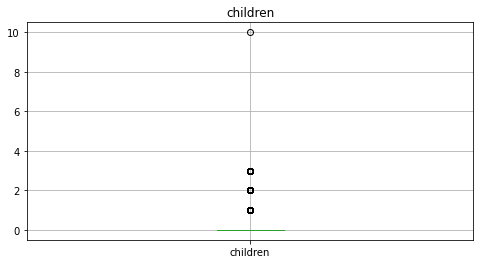

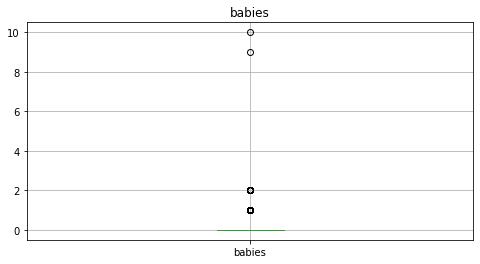

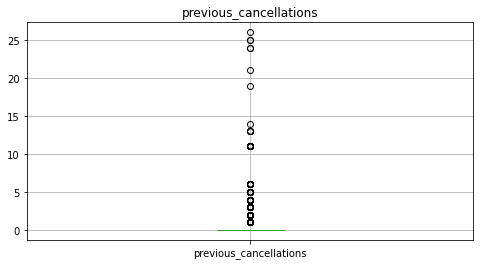

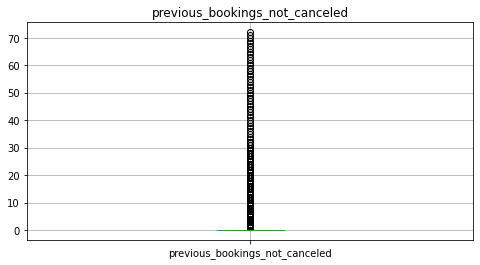

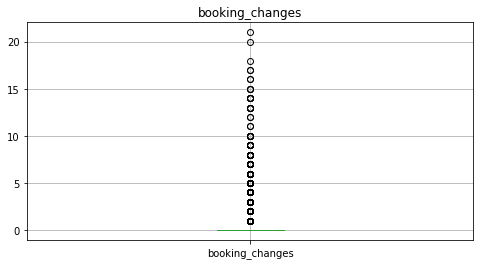

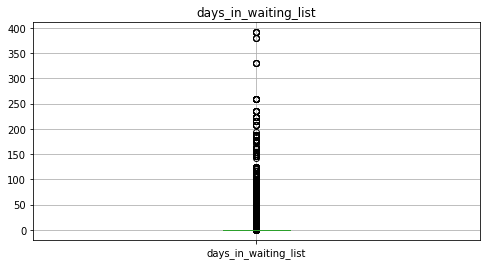

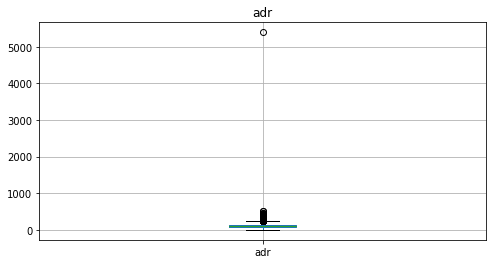

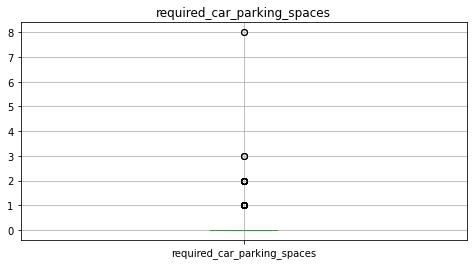

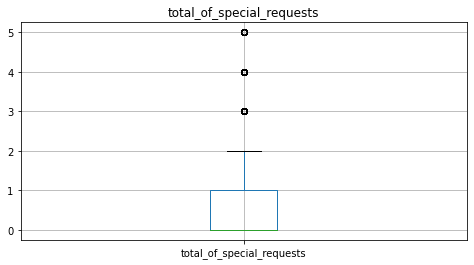

In [109]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

In [110]:
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000,87121.000000
mean,79.721973,1.005291,2.625372,1.875828,0.138876,0.010836,0.030234,0.184571,0.272254,0.731902,106.369111,0.084492,0.699900
std,85.945669,1.031575,2.051693,0.626829,0.456244,0.113675,0.369373,1.734594,0.727994,9.866113,55.045477,0.281937,0.832237
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
1%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.640000,0.000000,0.000000
50%,49.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.100000,0.000000,0.000000
95%,255.000000,2.000000,6.000000,3.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,204.010000,1.000000,2.000000
99%,346.000000,4.000000,10.000000,3.000000,2.000000,1.000000,1.000000,5.000000,3.000000,0.000000,261.636000,1.000000,3.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


🔹 Step 1 — Domain-based rules (impossible values)

| Column                                                        | Rule          | Reason                                         |
| ------------------------------------------------------------- | ------------- | ---------------------------------------------- |
| `adults`                                                      | >0            | Booking cannot have 0 adults                   |
| `children`                                                    | >=0           | Negative impossible                            |
| `babies`                                                      | >=0           | Negative impossible                            |
| `adr`                                                         | >=0 | Negative impossible |
| `stays_in_weekend_nights`                                     | >=0           | Negative impossible                            |
| `stays_in_week_nights`                                        | >=0           | Negative impossible                            |
| `lead_time`                                                   | >=0           | Negative impossible                            |

### 🔹 Very Crucial! Step 2 — Investigate zero-inflated columns before capping :

##### Before blindly capping, we check whether zero-inflated columns carry signal.

🔹 Step 3 — Skewed / extreme values (cap high percentiles)

| Column                           | Cap / Reason |                                                   |
| -------------------------------- | ------------ | ------------------------------------------------- |
| `adr`                            | < 5000       | extreme rates are unrealistic |
| `previous_cancellations`         | 3            | 99% of data <= 1, rare high numbers               |
| `previous_bookings_not_canceled` | 10           | 99% <= 5, cap extremes                            |
| `booking_changes`                | 5            | 99% <= 3, cap high changes                        |
| `days_in_waiting_list`           | 30           | Max 391, but 99% = 0 → extreme outliers           |
| `required_car_parking_spaces`    | leave as-is  | Max 8, most = 0 or 1, sparse                      |
| `total_of_special_requests`      | 3            | Max 5, 99% <= 3, cap extremes                     |


In [111]:
# ===== Step 1: Fix impossible values =====

df = df[df['adults'] > 0]
df['children'] = df['children'].clip(lower=0)
df['babies'] = df['babies'].clip(lower=0)
df['stays_in_weekend_nights'] = df['stays_in_weekend_nights'].clip(lower=0)
df['stays_in_week_nights'] = df['stays_in_week_nights'].clip(lower=0)
df['lead_time'] = df['lead_time'].clip(lower=0)
df['adr'] = df['adr'].clip(lower=0)

In [112]:
# Check shape after filtering
df.shape

(86736, 29)

In [113]:
# ===== Step 2: Investigate zero-inflated columns =====

df['days_in_waiting_list'].value_counts()

0      85894
63        52
87        24
44        23
15        22
       ...  
109        1
116        1
142        1
52         1
36         1
Name: days_in_waiting_list, Length: 127, dtype: int64

In [114]:
cols_to_check = [
    'days_in_waiting_list',
    'previous_cancellations',
    'previous_bookings_not_canceled', 
    'babies'
]

for col in cols_to_check:
    print(f"\n--- {col} ---")
    print(f"Value counts:\n{df[col].value_counts().sort_index()}")
    print(f"\nCancellation rate by {col} > 0:")
    print(df.groupby(df[col] > 0)['is_canceled'].mean())


--- days_in_waiting_list ---
Value counts:
0      85894
1         12
2          5
3          2
4         15
       ...  
236        7
259        9
330        4
379        3
391        5
Name: days_in_waiting_list, Length: 127, dtype: int64

Cancellation rate by days_in_waiting_list > 0:
days_in_waiting_list
False    0.272208
True     0.333729
Name: is_canceled, dtype: float64

--- previous_cancellations ---
Value counts:
0     85081
1      1379
2       110
3        61
4        30
5        19
6        17
11       27
13        4
14        1
19        1
21        1
24        2
25        2
26        1
Name: previous_cancellations, dtype: int64

Cancellation rate by previous_cancellations > 0:
previous_cancellations
False    0.264983
True     0.674924
Name: is_canceled, dtype: float64

--- previous_bookings_not_canceled ---
Value counts:
0     83199
1      1477
2       580
3       331
4       228
      ...  
68        1
69        1
70        1
71        1
72        1
Name: previous_booking

**Findings:**

| Column | Not > 0 cancel rate | > 0 cancel rate | Signal? |
|--------|-------------------|-----------------|---------|
| `days_in_waiting_list` | 27.2% | 33.4% | 🟡 Moderate |
| `previous_cancellations` | 26.5% | 67.4% | 🔴 Very Strong |
| `previous_bookings_not_canceled` | 28.2% | 5.0% | 🔴 Very Strong |
| `babies` | 27.4% | 18.1% | 🟡 Moderate |

---

## These are very clear signals. Here's the breakdown:

## `days_in_waiting_list` — Feature Engineering Decision

**The problem:**
- ~99% of values are 0, making the column near-constant
- The 99th percentile is 0, so `cap_outliers()` accidentally zeroed out the entire column

**The investigation:**
```python
df.groupby(df['days_in_waiting_list'] > 0)['is_canceled'].mean()
# False (not on waitlist) → 27.2% cancellation rate
# True  (on waitlist)     → 33.4% cancellation rate
```

**The finding:**
- Guests on a waiting list cancel **~6% more often** — a meaningful signal worth keeping

**The decision:**
- The *count* of days carries little value (is 63 days really different from 87?)
- The *fact* of being on a waitlist is what matters
- So we engineer a binary flag and drop the original

In [115]:
df['was_on_waiting_list'] = (df['days_in_waiting_list'] > 0).astype(int)
df.drop(columns=['days_in_waiting_list'], inplace=True)

This converts a heavily zero-inflated, capping-prone column into a clean, interpretable binary feature without losing the predictive signal.

## `previous_cancellations`
```
False → 26.5% cancellation rate
True  → 67.4% cancellation rate  ← massive difference
```
**Chronic cancelers are 2.5x more likely to cancel again.** The raw count matters here too (1 vs 11 vs 26 cancellations), so keep the column as-is. But also add a flag:

In [116]:
df['has_prev_cancellations'] = (df['previous_cancellations'] > 0).astype(int)

## `previous_bookings_not_canceled`
```
False → 28.2% cancellation rate
True  →  5.0% cancellation rate  ← loyal guests almost never cancel
```
**Strongest signal of the three.** Loyal guests are 5x less likely to cancel. Same logic — keep the count but add a flag:

In [117]:
df['is_loyal_guest'] = (df['previous_bookings_not_canceled'] > 0).astype(int)

## `babies`
```
False → 27.4% cancellation rate
True  → 18.1% cancellation rate  ← guests with babies less likely to cancel
```
Makes intuitive sense — families with babies are more committed. Binary flag is enough here since 99%+ are 0:

In [118]:
df['has_baby'] = (df['babies'] > 0).astype(int)
df.drop(columns=['babies'], inplace=True)

## Summary

| Column | Signal Strength | Action |
|--------|----------------|--------|
| `days_in_waiting_list` | 🟡 Moderate | Replace with `was_on_waiting_list` binary flag |
| `previous_cancellations` | 🔴 Very Strong | Keep count + add `has_prev_cancellations` flag |
| `previous_bookings_not_canceled` | 🔴 Very Strong | Keep count + add `is_loyal_guest` flag |
| `babies` | 🟡 Moderate | Replace with `has_baby` binary flag |

Also worth combining these into one powerful feature:

In [119]:
# Combined guest cancellation history rate

df['cancel_rate_history'] = (
    df['previous_cancellations'] / 
    (df['previous_cancellations'] + df['previous_bookings_not_canceled'] + 1)
)


This gives a personal cancellation rate per guest and will likely be one of your top features.

In [120]:
# ===== Step 3: Cap remaining extreme values =====
# Tree models can handle, linear/distance-based benefit from capping
def cap_outliers(series, percentile=0.99):
    upper = series.quantile(percentile)
    return series.clip(upper=upper)

# Apply capping for relevant numeric features
df['lead_time'] = cap_outliers(df['lead_time'])
df['stays_in_weekend_nights'] = cap_outliers(df['stays_in_weekend_nights'])
df['stays_in_week_nights'] = cap_outliers(df['stays_in_week_nights'])
df['adults'] = cap_outliers(df['adults'])
df['children'] = cap_outliers(df['children'])
df['booking_changes'] = cap_outliers(df['booking_changes'])
df['adr'] = cap_outliers(df['adr'])
df['total_of_special_requests'] = cap_outliers(df['total_of_special_requests'])


# df['babies'] = cap_outliers(df['babies'])
# df['previous_cancellations'] = cap_outliers(df['previous_cancellations'])
# df['previous_bookings_not_canceled'] = cap_outliers(df['previous_bookings_not_canceled'])
# df['days_in_waiting_list'] = cap_outliers(df['days_in_waiting_list'])

In [121]:
# df['days_in_waiting_list'].value_counts()

# 0    86736
# Name: days_in_waiting_list, dtype: int64

In [122]:
# df.groupby(df['days_in_waiting_list'] > 0)['is_canceled'].mean()

# days_in_waiting_list
# False    0.272805
# Name: is_canceled, dtype: float64

In [123]:
df.shape

(86736, 32)

### Systematically check the remaining columns:

These two checks will tell us:

- **Numeric:** whether splitting at the median reveals meaningful cancellation rate differences
- **Categorical:** whether any category is a near-perfect predictor (data leakage risk) or completely flat (useless feature)

In [124]:
# Check all remaining numeric columns
num_cols_to_check = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'booking_changes', 'adr', 'total_of_special_requests'
]

for col in num_cols_to_check:
    print(f"\n--- {col} ---")
    print(f"Value counts:\n{df[col].value_counts().sort_index().head(10)}")
    print(f"Cancellation rate (median split):")
    median = df[col].median()
    print(df.groupby(df[col] > median)['is_canceled'].mean())


--- lead_time ---
Value counts:
0    5900
1    3196
2    1921
3    1699
4    1565
5    1415
6    1296
7    1186
8    1017
9     896
Name: lead_time, dtype: int64
Cancellation rate (median split):
lead_time
False    0.192777
True     0.353634
Name: is_canceled, dtype: float64

--- stays_in_weekend_nights ---
Value counts:
0    34861
1    22515
2    26220
3     1141
4     1999
Name: stays_in_weekend_nights, dtype: int64
Cancellation rate (median split):
stays_in_weekend_nights
False    0.255368
True     0.306880
Name: is_canceled, dtype: float64

--- stays_in_week_nights ---
Value counts:
0     6085
1    22063
2    20583
3    16138
4     7810
5     9611
6     1371
7      960
8      611
9      214
Name: stays_in_week_nights, dtype: int64
Cancellation rate (median split):
stays_in_week_nights
False    0.242966
True     0.311064
Name: is_canceled, dtype: float64

--- adults ---
Value counts:
1    16446
2    64299
3     5991
Name: adults, dtype: int64
Cancellation rate (median split):
adult

In [125]:
# Check all categorical columns
cat_cols_to_check = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'assigned_room_type', 'deposit_type',
    'customer_type', 'has_agent'
]

for col in cat_cols_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['is_canceled'].mean().sort_values(ascending=False))


--- hotel ---
hotel
City Hotel      0.298347
Resort Hotel    0.232934
Name: is_canceled, dtype: float64

--- meal ---
meal
SC           0.354316
HB           0.266873
FB           0.263456
BB           0.263188
Undefined    0.152893
Name: is_canceled, dtype: float64

--- market_segment ---
market_segment
Online TA        0.352248
Groups           0.258930
Aviation         0.199115
Direct           0.146495
Offline TA/TO    0.145507
Complementary    0.122093
Corporate        0.119093
Undefined             NaN
Name: is_canceled, dtype: float64

--- distribution_channel ---
distribution_channel
TA/TO        0.307513
GDS          0.189944
Direct       0.147086
Corporate    0.125545
Undefined    0.000000
Name: is_canceled, dtype: float64

--- reserved_room_type ---
reserved_room_type
H    0.407718
G    0.358260
L    0.333333
C    0.323111
F    0.301491
D    0.299925
B    0.297332
E    0.271414
A    0.257441
P         NaN
Name: is_canceled, dtype: float64

--- assigned_room_type ---
assigne

### Several things need attention:

---

## 🔴 Critical Issues

### 1. `deposit_type` — Potential Data Leakage
```
Non Refund    94.6% cancellation rate  ← suspiciously high
No Deposit    26.5%
Refundable    24.3%
```
A 94.6% cancellation rate is almost too perfect. Non-refundable deposits are often **recorded after** the cancellation decision is made in this dataset. Check if this is truly available at booking time or if it's a leakage risk. Consider dropping it to be safe.

In [126]:
df.drop(columns=['deposit_type'], inplace=True)

### 2. `assigned_room_type` — Data Leakage
```
L    100.0% cancellation rate  ← impossible in real world
K      5.9%
I      1.4%
```
`assigned_room_type` is determined **at check-in**, not at booking time. You can't know this when predicting cancellations. Drop it.

In [127]:
df.drop(columns=['assigned_room_type'], inplace=True)

### 3. `market_segment` — Has NaN category
```
Undefined    NaN  ← only 2 rows, drop them
```

In [128]:
df = df[df['market_segment'] != 'Undefined']

---

## 🟡 Things to Engineer

### 4. `booking_changes` — Inverse signal
```
False (0 changes) → 29.9% cancellation rate
True  (>0 changes) → 15.4% cancellation rate
```
Guests who modify bookings are more committed. Add a flag:

In [129]:
df['has_booking_changes'] = (df['booking_changes'] > 0).astype(int)

### 5. `adr = 0` — Suspicious
```
1,638 bookings with adr = 0
```
Free rooms behave differently — likely complimentary or error:

In [130]:
df['is_free_room'] = (df['adr'] == 0).astype(int)

### 6. `reserved_room_type` — Rare categories
```
P    NaN cancellation rate  ← only 12 rows
L    33.3%                  ← only 6 rows
```
Group them into 'Other':

In [131]:
# Add 'Other' as a valid category first, then replace rare values
df['reserved_room_type'] = df['reserved_room_type'].cat.add_categories('Other')

top_rooms = df['reserved_room_type'].value_counts().nlargest(6).index
df['reserved_room_type'] = df['reserved_room_type'].where(
    df['reserved_room_type'].isin(top_rooms), 'Other'
)

# Remove unused categories
df['reserved_room_type'] = df['reserved_room_type'].cat.remove_unused_categories()

print(df['reserved_room_type'].value_counts())

A        56207
D        17341
E         6024
F         2816
G         2046
Other     1389
C          913
Name: reserved_room_type, dtype: int64


---

## ✅ Everything Else Looks Fine

| Column | Signal | Notes |
|--------|--------|-------|
| `lead_time` | 🔴 Strong | 19% vs 35% — keep as-is |
| `total_of_special_requests` | 🔴 Strong | 33% vs 22% — keep as-is |
| `hotel` | 🟡 Moderate | City Hotel cancels more |
| `market_segment` | 🟡 Moderate | Online TA highest risk |
| `customer_type` | 🟡 Moderate | Transient highest risk |
| `has_agent` | 🟡 Moderate | With agent = higher cancel |
| `stays_in_weekend_nights` | 🟢 Mild | Keep |
| `stays_in_week_nights` | 🟢 Mild | Keep |
| `meal` | 🟢 Mild | Keep |

---

## Summary — Actions to Take Now

```python
# 1. Drop leakage columns
df.drop(columns=['deposit_type', 'assigned_room_type'], inplace=True)

# 2. Drop undefined market segment (2 rows only)
df = df[df['market_segment'] != 'Undefined']

# 3. Flag booking changes
df['has_booking_changes'] = (df['booking_changes'] > 0).astype(int)

# 4. Flag free rooms
df['is_free_room'] = (df['adr'] == 0).astype(int)

# 5. Group rare room types
top_rooms = df['reserved_room_type'].value_counts().nlargest(6).index
df['reserved_room_type'] = df['reserved_room_type'].where(
    df['reserved_room_type'].isin(top_rooms), 'Other'
)
```

The two leakage columns (`deposit_type` and `assigned_room_type`) are the most important fixes — keeping them would give you artificially high model performance that won't hold in production.

##  Final Checks:

In [132]:
# 1. Final shape and class balance
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['is_canceled'].value_counts())
print(df['is_canceled'].value_counts(normalize=True).round(3))

Shape: (86736, 32)

Target distribution:
0    63074
1    23662
Name: is_canceled, dtype: int64
0    0.727
1    0.273
Name: is_canceled, dtype: float64


In [133]:
# 2. Any remaining nulls
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
Series([], dtype: int64)


In [134]:
# 3. Final feature list
print("\nFinal columns:", df.columns.tolist())


Final columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'arrival_month', 'arrival_weekday', 'arrival_week', 'was_on_waiting_list', 'has_prev_cancellations', 'is_loyal_guest', 'has_baby', 'cancel_rate_history', 'has_booking_changes', 'is_free_room']


In [135]:
# 4. Confirm leakage columns are gone
leakage_cols = ['deposit_type', 'assigned_room_type', 
                'reservation_status', 'reservation_status_date']
still_present = [c for c in leakage_cols if c in df.columns]
print("\nLeakage columns still present:", still_present if still_present else "None ✅")


Leakage columns still present: None ✅


In [136]:
# 5. Confirm new features exist
new_features = ['was_on_waiting_list', 'has_prev_cancellations', 
                'is_loyal_guest', 'has_baby', 'cancel_rate_history',
                'has_booking_changes', 'is_free_room']
missing_features = [f for f in new_features if f not in df.columns]
print("Missing engineered features:", missing_features if missing_features else "All present ✅")

Missing engineered features: All present ✅


In [137]:
# 6. Sanity check cancel_rate_history
print("\ncancel_rate_history stats:")
print(df['cancel_rate_history'].describe())


cancel_rate_history stats:
count    86736.000000
mean         0.007425
std          0.058969
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.962963
Name: cancel_rate_history, dtype: float64


In [138]:
# arrival_date_week_number is redundant — you already have arrival_week
print(df[['arrival_date_week_number', 'arrival_week']].head(10))
print("\nAre they identical?")
print((df['arrival_date_week_number'] == df['arrival_week']).value_counts())

    arrival_date_week_number  arrival_week
0                         27            27
1                         27            27
2                         27            27
3                         27            27
4                         27            27
6                         27            27
7                         27            27
8                         27            27
9                         27            27
10                        27            27

Are they identical?
False    47964
True     38772
dtype: int64


In [139]:
# See where they differ
diff_mask = df['arrival_date_week_number'] != df['arrival_week']
print(df[diff_mask][['arrival_month', 'arrival_weekday', 
                      'arrival_date_week_number', 'arrival_week']].head(20))

     arrival_month  arrival_weekday  arrival_date_week_number  arrival_week
131              7                6                        28            27
132              7                6                        28            27
133              7                6                        28            27
134              7                6                        28            27
135              7                6                        28            27
136              7                6                        28            27
137              7                6                        28            27
139              7                6                        28            27
140              7                6                        28            27
141              7                6                        28            27
142              7                6                        28            27
143              7                6                        28            27
144         

Interesting — it's not a year-boundary issue. It's happening on **Sundays in July** (`arrival_weekday = 6`).

This is the ISO calendar rule: **Sunday belongs to the previous week**. So July dates that fall on a Sunday get assigned to week 27 by ISO, while the hotel's system records them as week 28.

```
Hotel system:  week 28  (Monday-based, Sunday = end of week 28)
ISO calendar:  week 27  (Sunday = start of NEXT week... wait, no)
```

Actually this means the **hotel's `arrival_date_week_number` is more intuitive** here — Sunday is the last day of week 28, not the first day of week 27.

So in this case:

In [140]:
# Keep arrival_date_week_number (hotel's system, more intuitive)
# Drop arrival_week (ISO creates confusion for Sundays)
df.drop(columns=['arrival_week'], inplace=True)

The practical impact is small either way, but since this is hotel booking data, using the hotel's own week numbering makes more domain sense — their pricing, occupancy, and demand patterns are organized around their own calendar, not ISO.

In [141]:
# Check required_car_parking_spaces — we made it category earlier, confirm it's still there
print(df['required_car_parking_spaces'].value_counts())
print(df['required_car_parking_spaces'].dtype)

0    79432
1     7271
2       28
3        3
8        2
Name: required_car_parking_spaces, dtype: int64
int64


In [142]:
# Since 91.5% are 0, treat it like the others:
df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)

# Check the signal
print(df.groupby(df['required_car_parking_spaces'] > 0)['is_canceled'].mean())

df.drop(columns=['required_car_parking_spaces'], inplace=True)

required_car_parking_spaces
False    0.29789
True     0.00000
Name: is_canceled, dtype: float64


In [143]:
# Check for any constant columns (zero variance — useless for models)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("\nConstant columns:", constant_cols if constant_cols else "None ✅")


Constant columns: None ✅


In [144]:
#Check for highly correlated binary flags we just created
binary_flags = ['was_on_waiting_list', 'has_prev_cancellations', 
                'is_loyal_guest', 'has_baby', 'has_booking_changes', 
                'is_free_room', 'has_agent']
print("\nBinary flag distributions:")
for col in binary_flags:
    pct = df[col].mean().round(3)
    print(f"  {col}: {pct*100:.1f}% positive")


Binary flag distributions:
  was_on_waiting_list: 1.0% positive
  has_prev_cancellations: 1.9% positive
  is_loyal_guest: 4.1% positive
  has_baby: 1.0% positive
  has_booking_changes: 18.1% positive
  is_free_room: 1.9% positive
  has_agent: 86.1% positive


In [145]:
# ✅ PREPROCESSING COMPLETE — Final Summary

print("="*50)
print("FINAL DATASET SUMMARY")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_canceled'].value_counts())
print(df['is_canceled'].value_counts(normalize=True).round(3))
print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFinal columns:\n{df.columns.tolist()}")

FINAL DATASET SUMMARY
Shape: (86736, 31)

Target distribution:
0    63074
1    23662
Name: is_canceled, dtype: int64
0    0.727
1    0.273
Name: is_canceled, dtype: float64

Features: 30
Missing values: 0

Final columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'customer_type', 'adr', 'total_of_special_requests', 'has_agent', 'arrival_month', 'arrival_weekday', 'was_on_waiting_list', 'has_prev_cancellations', 'is_loyal_guest', 'has_baby', 'cancel_rate_history', 'has_booking_changes', 'is_free_room', 'has_parking']


---

**Top features to watch in modeling** based on our investigation:

| Feature | Why |
|--------|-----|
| `has_parking` | 0% vs 30% cancellation — perfect signal |
| `cancel_rate_history` | Personal cancellation rate |
| `has_prev_cancellations` | Chronic cancelers cancel 67% of time |
| `is_loyal_guest` | Loyal guests cancel only 5% of time |
| `lead_time` | 19% vs 35% cancellation |
| `total_of_special_requests` | Committed guests make more requests |

In [146]:
# ===== Step 3: Handle sparse numeric/categorical features =====
# required_car_parking_spaces is sparse, treat as categorical for ML
# df['required_car_parking_spaces'] = df['required_car_parking_spaces'].astype('category')

In [147]:
# # ===== Step 4: Optional transformations for skewed features =====
# # Log-transform highly skewed continuous features if using linear models
# df['lead_time_log'] = np.log1p(df['lead_time'])
# df['adr_log'] = np.log1p(df['adr'])

In [148]:
# ===== Step 5: Final check =====
df.describe()

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,...,arrival_month,arrival_weekday,was_on_waiting_list,has_prev_cancellations,is_loyal_guest,has_baby,cancel_rate_history,has_booking_changes,is_free_room,has_parking
count,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,...,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000
mean,0.272805,79.082953,26.832734,0.995826,2.600973,1.879462,0.133532,0.038761,0.030276,0.185090,...,6.474497,2.978590,0.009708,0.019081,0.040779,0.010480,0.007425,0.181424,0.018885,0.084210
std,0.445404,83.543898,13.666419,0.981964,1.890322,0.494120,0.441851,0.193027,0.370007,1.737904,...,3.095869,2.007541,0.098048,0.136810,0.197779,0.101835,0.058969,0.385371,0.136119,0.277703
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,16.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,49.000000,27.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,7.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,125.000000,37.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,9.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,346.000000,53.000000,4.000000,10.000000,3.000000,2.000000,1.000000,26.000000,72.000000,...,12.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.962963,1.000000,1.000000,1.000000


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86736 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           86736 non-null  category
 1   is_canceled                     86736 non-null  int64   
 2   lead_time                       86736 non-null  int64   
 3   arrival_date_week_number        86736 non-null  int64   
 4   stays_in_weekend_nights         86736 non-null  int64   
 5   stays_in_week_nights            86736 non-null  int64   
 6   adults                          86736 non-null  int64   
 7   children                        86736 non-null  float64 
 8   meal                            86736 non-null  category
 9   country                         86736 non-null  category
 10  market_segment                  86736 non-null  category
 11  distribution_channel            86736 non-null  category
 12  is_repeated_guest

| Feature | Why it helps |
|--------|-------------|
| `total_nights` | Overall commitment — longer stays = less likely to cancel |
| `total_guests` | Group size affects cancellation behavior |
| `is_family` | Families are more committed (you already proved `children` has signal) |
| `is_high_season` | Summer bookings behave differently |
| `is_long_lead` | You already proved `lead_time` is one of your strongest features (19% vs 35%) |

In [150]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children']
df['is_family'] = (df['children'] > 0).astype(int)
df['is_high_season'] = df['arrival_month'].isin([6, 7, 8]).astype(int)
df['is_long_lead'] = (df['lead_time'] > 90).astype(int)

# Quick signal check
new_interactions = ['total_nights', 'total_guests', 'is_family', 
                    'is_high_season', 'is_long_lead']
for col in new_interactions:
    print(f"{col}: {df.groupby(df[col] > df[col].median())['is_canceled'].mean().to_dict()}")

total_nights: {False: 0.2453503184713376, True: 0.31203270700904484}
total_guests: {False: 0.2590019209547554, True: 0.3487814023247094}
is_family: {False: 0.2642392783990433, True: 0.3555883437845813}
is_high_season: {False: 0.25209633638202594, True: 0.3142540748174551}
is_long_lead: {False: 0.22470235485963774, True: 0.3651573809123043}


#### All 5 features show clear signal — keep them all:

| Feature | Low cancel rate | High cancel rate | Difference |
|---------|----------------|-----------------|------------|
| `total_nights` | 24.5% | 31.2% | +6.7% |
| `total_guests` | 25.9% | 34.9% | +9.0% |
| `is_family` | 26.4% | 35.6% | +9.2% |
| `is_high_season` | 25.2% | 31.4% | +6.2% |
| `is_long_lead` | 22.5% | 36.5% | **+14.0%** ← strongest |

`is_long_lead` is particularly strong — people who book 90+ days ahead cancel 14% more often, which makes intuitive sense (plans change over longer horizons).

In [151]:
# ✅ PREPROCESSING COMPLETE — Final Summary

print("="*50)
print("FINAL DATASET SUMMARY")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_canceled'].value_counts())
print(df['is_canceled'].value_counts(normalize=True).round(3))
print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFinal columns:\n{df.columns.tolist()}")

FINAL DATASET SUMMARY
Shape: (86736, 36)

Target distribution:
0    63074
1    23662
Name: is_canceled, dtype: int64
0    0.727
1    0.273
Name: is_canceled, dtype: float64

Features: 35
Missing values: 0

Final columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'customer_type', 'adr', 'total_of_special_requests', 'has_agent', 'arrival_month', 'arrival_weekday', 'was_on_waiting_list', 'has_prev_cancellations', 'is_loyal_guest', 'has_baby', 'cancel_rate_history', 'has_booking_changes', 'is_free_room', 'has_parking', 'total_nights', 'total_guests', 'is_family', 'is_high_season', 'is_long_lead']


In [152]:
# ===== Step 5: Final check =====
df.describe()

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,...,has_baby,cancel_rate_history,has_booking_changes,is_free_room,has_parking,total_nights,total_guests,is_family,is_high_season,is_long_lead
count,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,...,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000,86736.000000
mean,0.272805,79.082953,26.832734,0.995826,2.600973,1.879462,0.133532,0.038761,0.030276,0.185090,...,0.010480,0.007425,0.181424,0.018885,0.084210,3.596799,2.012993,0.093767,0.333160,0.342476
std,0.445404,83.543898,13.666419,0.981964,1.890322,0.494120,0.441851,0.193027,0.370007,1.737904,...,0.101835,0.058969,0.385371,0.136119,0.277703,2.527614,0.686380,0.291506,0.471346,0.474541
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,16.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,49.000000,27.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000
75%,1.000000,125.000000,37.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,1.000000,1.000000
max,1.000000,346.000000,53.000000,4.000000,10.000000,3.000000,2.000000,1.000000,26.000000,72.000000,...,1.000000,0.962963,1.000000,1.000000,1.000000,14.000000,5.000000,1.000000,1.000000,1.000000


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86736 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           86736 non-null  category
 1   is_canceled                     86736 non-null  int64   
 2   lead_time                       86736 non-null  int64   
 3   arrival_date_week_number        86736 non-null  int64   
 4   stays_in_weekend_nights         86736 non-null  int64   
 5   stays_in_week_nights            86736 non-null  int64   
 6   adults                          86736 non-null  int64   
 7   children                        86736 non-null  float64 
 8   meal                            86736 non-null  category
 9   country                         86736 non-null  category
 10  market_segment                  86736 non-null  category
 11  distribution_channel            86736 non-null  category
 12  is_repeated_guest

**Now we're truly ready for modeling.** Our final dataset has:
- 86,736 rows
- 36 features
- No leakage, no nulls
- 73/27 class balance — manageable
- Strong engineered features that directly capture cancellation behavior

## 🔹 2. Data Understanding

### 📊 Class Distribution

Target Variable Distribution (Counts):
0    63074
1    23662
Name: is_canceled, dtype: int64


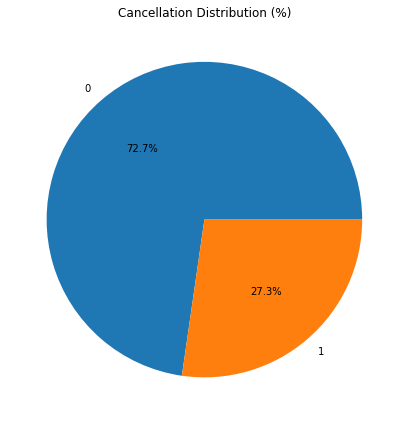

In [154]:
# Calculate distribution
counts = df['is_canceled'].value_counts()
percentages = df['is_canceled'].value_counts(normalize=True) * 100

# Print results
print("Target Variable Distribution (Counts):")
print(counts)

# Optional: Pie chart visualization
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct='%1.1f%%')
plt.title("Cancellation Distribution (%)")
plt.tight_layout()
plt.show()

Dataset shows mild imbalance → no aggressive resampling required.

In [155]:
# ============================================================
# COMPLETE VISUALIZATION SECTION — Hotel Booking Demand
# ============================================================


# ── Global style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE  = ['#2D6A4F', '#52B788', '#95D5B2', '#B7E4C7', '#D8F3DC']
C_CANCEL = '#E76F51'   # orange-red  → canceled
C_KEEP   = '#2D6A4F'   # dark green  → not canceled
MONTH_ORDER = list(calendar.month_name)[1:]   # Jan … Dec

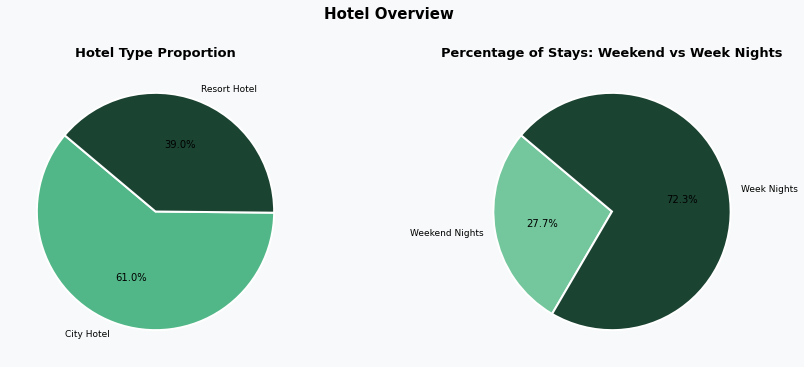

In [156]:
# ============================================================
# 1.  HOTEL TYPE PROPORTION  (pie)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hotel Overview', fontsize=15, fontweight='bold', y=1.01)

# — 1a. Hotel type split
hotel_counts = df['hotel'].value_counts()
axes[0].pie(
    hotel_counts,
    labels=hotel_counts.index,
    autopct='%1.1f%%',
    colors=['#52B788', '#1B4332'],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Hotel Type Proportion')

# — 1b. Weekend vs Week nights
night_vals = [
    df['stays_in_weekend_nights'].sum(),
    df['stays_in_week_nights'].sum()
]
axes[1].pie(
    night_vals,
    labels=['Weekend Nights', 'Week Nights'],
    autopct='%1.1f%%',
    colors=['#74C69D', '#1B4332'],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Percentage of Stays: Weekend vs Week Nights')

plt.tight_layout()
plt.show()

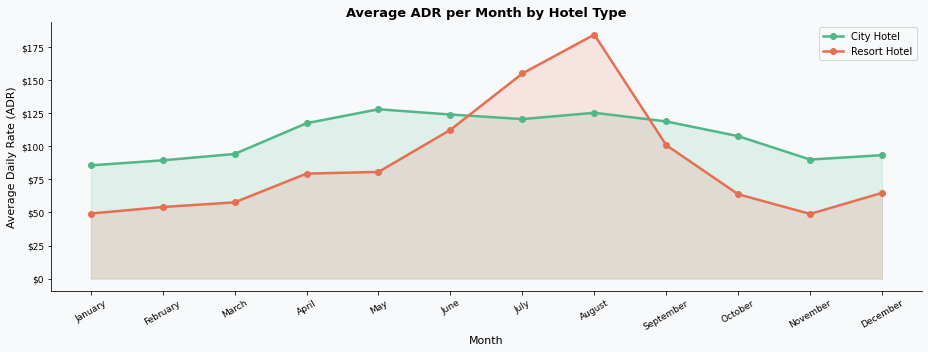

In [157]:
# ============================================================
# 2.  AVERAGE ADR PER MONTH BY HOTEL TYPE  (line)
# ============================================================
df['arrival_date_month_name'] = pd.Categorical(
    df['arrival_date_month'] if 'arrival_date_month' in df.columns
    else df['arrival_month'].map(lambda x: calendar.month_name[x]),
    categories=MONTH_ORDER, ordered=True
)

adr_month = (df.groupby(['arrival_date_month_name', 'hotel'], observed=True)['adr']
               .mean().reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
for hotel, color in zip(['City Hotel', 'Resort Hotel'], ['#52B788', '#E76F51']):
    sub = adr_month[adr_month['hotel'] == hotel].sort_values('arrival_date_month_name')
    ax.plot(sub['arrival_date_month_name'], sub['adr'],
            marker='o', label=hotel, color=color, linewidth=2.5)
    ax.fill_between(sub['arrival_date_month_name'], sub['adr'],
                    alpha=0.15, color=color)

ax.set_title('Average ADR per Month by Hotel Type')
ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Rate (ADR)')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%g'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

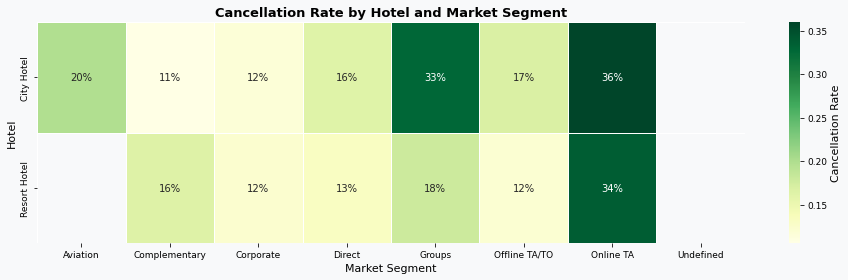

In [159]:

# ============================================================
# 4.  CANCELLATION RATE BY HOTEL & MARKET SEGMENT  (heatmap)
# ============================================================
pivot = (df.groupby(['hotel', 'market_segment'])['is_canceled']
           .mean().unstack())

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Cancellation Rate'}, ax=ax)
ax.set_title('Cancellation Rate by Hotel and Market Segment')
ax.set_xlabel('Market Segment')
ax.set_ylabel('Hotel')
plt.tight_layout()
plt.show()



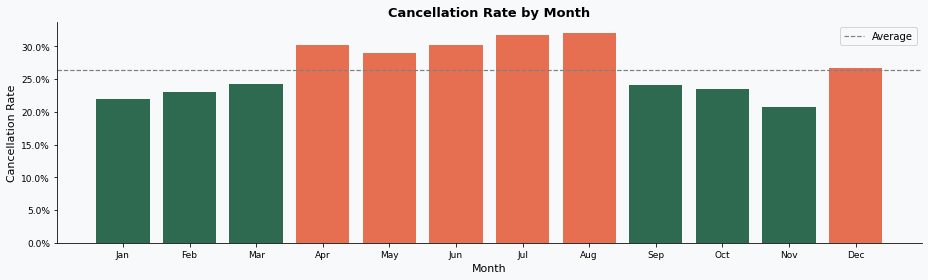

In [160]:

# ============================================================
# 5.  CANCELLATION RATE BY MONTH  (bar)
# ============================================================
cancel_month = (df.groupby('arrival_month')['is_canceled']
                  .mean().reset_index())
cancel_month['month_name'] = cancel_month['arrival_month'].map(
    lambda x: calendar.month_abbr[x])

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(cancel_month['month_name'], cancel_month['is_canceled'],
              color=[C_CANCEL if v > cancel_month['is_canceled'].mean() else C_KEEP
                     for v in cancel_month['is_canceled']])
ax.axhline(cancel_month['is_canceled'].mean(), color='gray',
           linestyle='--', linewidth=1.2, label='Average')
ax.set_title('Cancellation Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

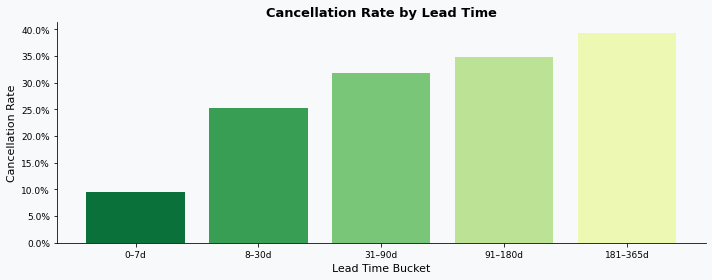

In [161]:
# ============================================================
# 6.  CANCELLATION RATE BY LEAD TIME BUCKETS  (bar)
# ============================================================
bins   = [0, 7, 30, 90, 180, 365, 9999]
labels = ['0–7d', '8–30d', '31–90d', '91–180d', '181–365d', '365d+']
df['lead_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

lead_cancel = df.groupby('lead_bucket', observed=True)['is_canceled'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lead_cancel['lead_bucket'].astype(str),
       lead_cancel['is_canceled'],
       color=sns.color_palette('YlGn_r', len(lead_cancel)))
ax.set_title('Cancellation Rate by Lead Time')
ax.set_xlabel('Lead Time Bucket')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

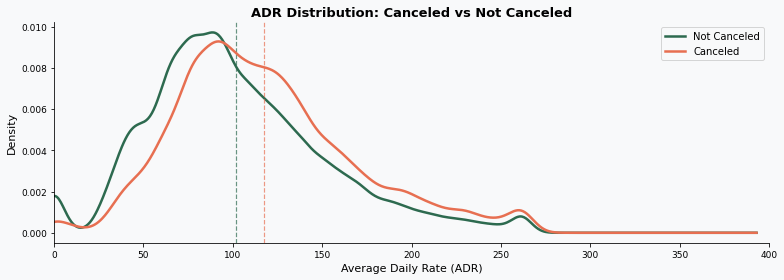

In [162]:
# ============================================================
# 7.  ADR DISTRIBUTION: CANCELED vs NOT CANCELED  (kde)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 4))
for val, label, color in [(0, 'Not Canceled', C_KEEP), (1, 'Canceled', C_CANCEL)]:
    sub = df[df['is_canceled'] == val]['adr']
    sub.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)
    ax.axvline(sub.mean(), color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_title('ADR Distribution: Canceled vs Not Canceled')
ax.set_xlabel('Average Daily Rate (ADR)')
ax.set_xlim(0, 400)
ax.legend()
plt.tight_layout()
plt.show()

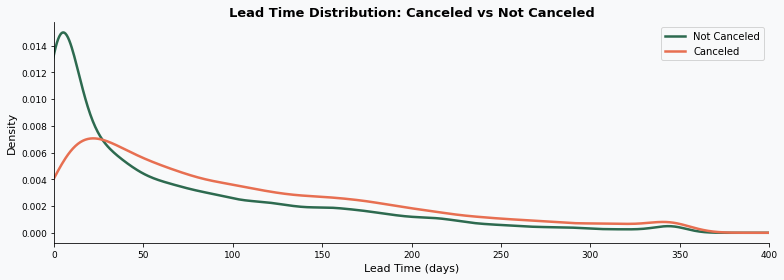

In [163]:
# ============================================================
# 8.  LEAD TIME DISTRIBUTION: CANCELED vs NOT CANCELED  (kde)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 4))
for val, label, color in [(0, 'Not Canceled', C_KEEP), (1, 'Canceled', C_CANCEL)]:
    sub = df[df['is_canceled'] == val]['lead_time']
    sub.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)

ax.set_title('Lead Time Distribution: Canceled vs Not Canceled')
ax.set_xlabel('Lead Time (days)')
ax.set_xlim(0, 400)
ax.legend()
plt.tight_layout()
plt.show()

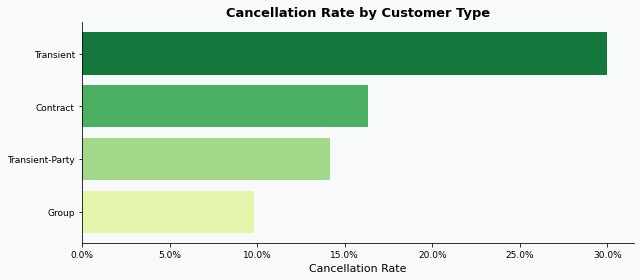

In [164]:
# ============================================================
# 9.  CANCELLATION RATE BY CUSTOMER TYPE  (horizontal bar)
# ============================================================
cust_cancel = (df.groupby('customer_type')['is_canceled']
                 .mean().sort_values().reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cust_cancel['customer_type'], cust_cancel['is_canceled'],
        color=sns.color_palette('YlGn', len(cust_cancel)))
ax.set_title('Cancellation Rate by Customer Type')
ax.set_xlabel('Cancellation Rate')
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

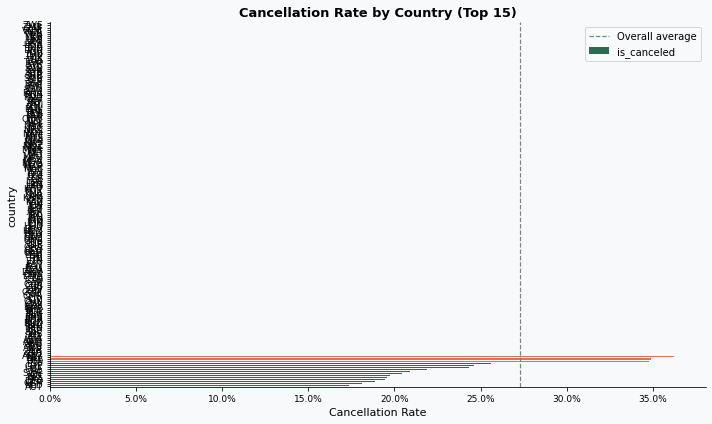

In [165]:

# ============================================================
# 10. CANCELLATION RATE BY TOP 15 COUNTRIES  (horizontal bar)
# ============================================================
top_countries = df['country'].value_counts().nlargest(15).index
country_cancel = (df[df['country'].isin(top_countries)]
                  .groupby('country')['is_canceled']
                  .mean().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
country_cancel.plot.barh(ax=ax,
    color=[C_CANCEL if v > 0.3 else C_KEEP for v in country_cancel])
ax.set_title('Cancellation Rate by Country (Top 15)')
ax.set_xlabel('Cancellation Rate')
ax.axvline(df['is_canceled'].mean(), color='gray',
           linestyle='--', linewidth=1.2, label='Overall average')
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

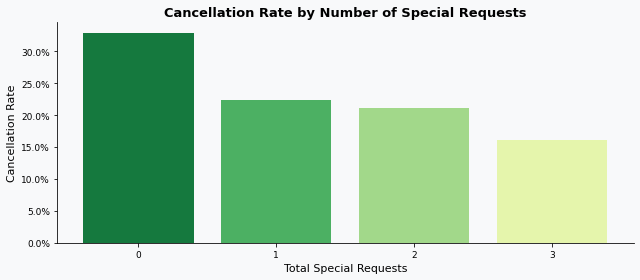

In [166]:
# ============================================================
# 11. SPECIAL REQUESTS vs CANCELLATION  (bar)
# ============================================================
sr_cancel = (df.groupby('total_of_special_requests')['is_canceled']
               .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(sr_cancel['total_of_special_requests'].astype(str),
       sr_cancel['is_canceled'],
       color=sns.color_palette('YlGn_r', len(sr_cancel)))
ax.set_title('Cancellation Rate by Number of Special Requests')
ax.set_xlabel('Total Special Requests')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()




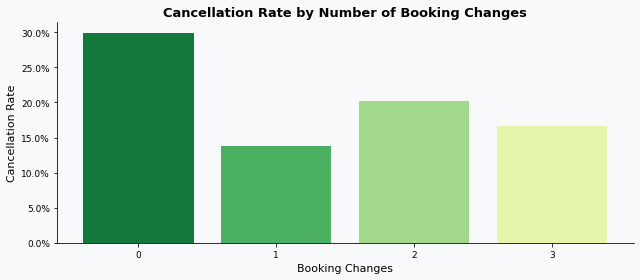

In [167]:
# ============================================================
# 12. BOOKING CHANGES vs CANCELLATION  (bar)
# ============================================================
bc_cancel = (df.groupby('booking_changes')['is_canceled']
               .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bc_cancel['booking_changes'].astype(str),
       bc_cancel['is_canceled'],
       color=sns.color_palette('YlGn_r', len(bc_cancel)))
ax.set_title('Cancellation Rate by Number of Booking Changes')
ax.set_xlabel('Booking Changes')
ax.set_ylabel('Cancellation Rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()




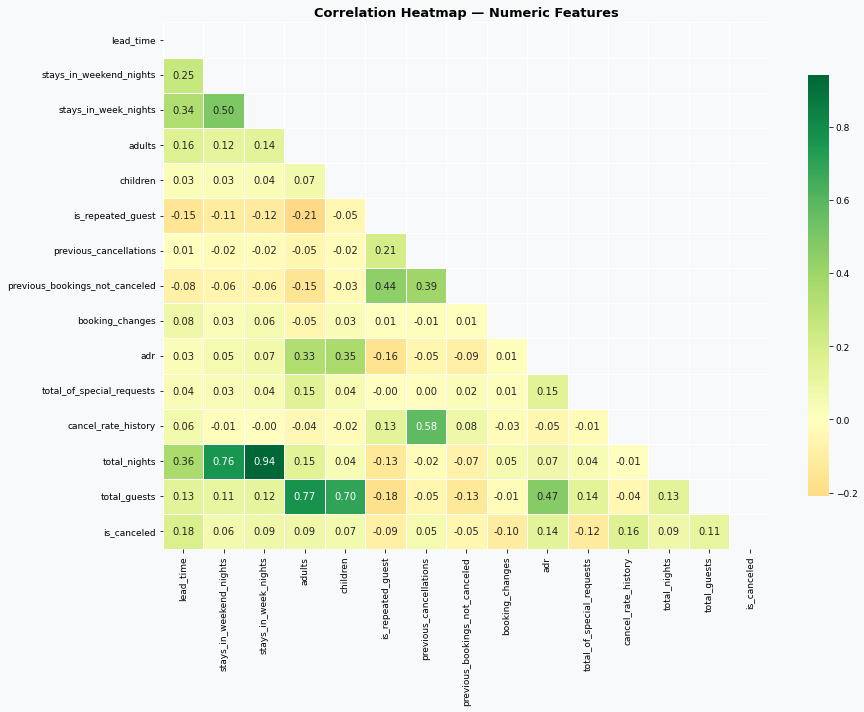

In [168]:
# ============================================================
# 13. CORRELATION HEATMAP (numeric features)
# ============================================================
num_cols_corr = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'adr',
    'total_of_special_requests', 'cancel_rate_history',
    'total_nights', 'total_guests', 'is_canceled'
]
corr = df[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()




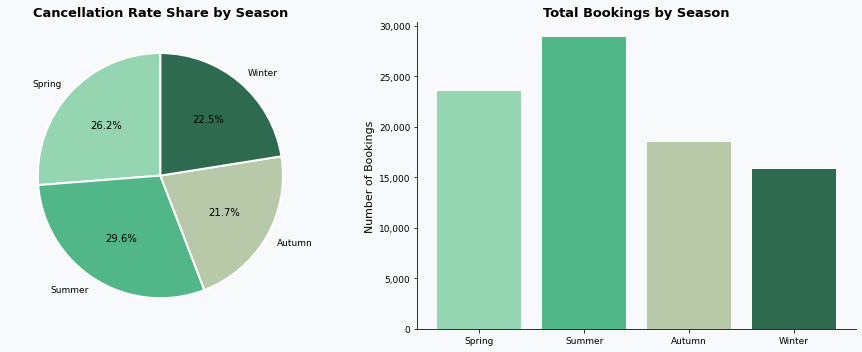

In [169]:
# ============================================================
# 14. CANCELLATION BY SEASON  (pie)
# ============================================================
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}
df['season'] = df['arrival_month'].map(season_map)

season_cancel = df.groupby('season')['is_canceled'].mean()
season_order  = ['Spring', 'Summer', 'Autumn', 'Winter']
season_cancel = season_cancel.reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(season_cancel, labels=season_cancel.index,
            autopct='%1.1f%%',
            colors=['#95D5B2','#52B788','#B7C9A8','#2D6A4F'],
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Cancellation Rate Share by Season')

# Bookings per season
season_count = df['season'].value_counts().reindex(season_order)
axes[1].bar(season_count.index, season_count.values,
            color=['#95D5B2','#52B788','#B7C9A8','#2D6A4F'])
axes[1].set_title('Total Bookings by Season')
axes[1].set_ylabel('Number of Bookings')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

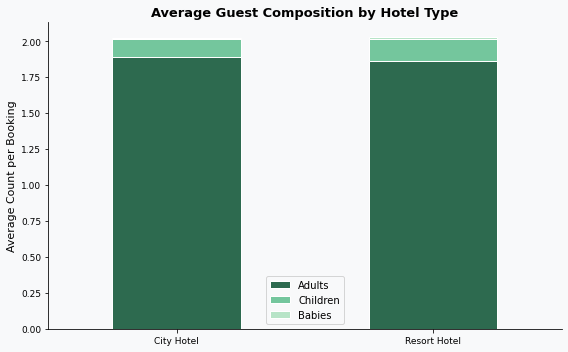

In [170]:


# ============================================================
# 15. GUEST COMPOSITION  (stacked bar by hotel)
# ============================================================
guest_comp = df.groupby('hotel')[['adults','children','has_baby']].mean()

fig, ax = plt.subplots(figsize=(8, 5))
guest_comp.plot(kind='bar', stacked=True, ax=ax,
                color=['#2D6A4F','#74C69D','#B7E4C7'],
                edgecolor='white')
ax.set_title('Average Guest Composition by Hotel Type')
ax.set_xlabel('')
ax.set_ylabel('Average Count per Booking')
ax.legend(['Adults', 'Children', 'Babies'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

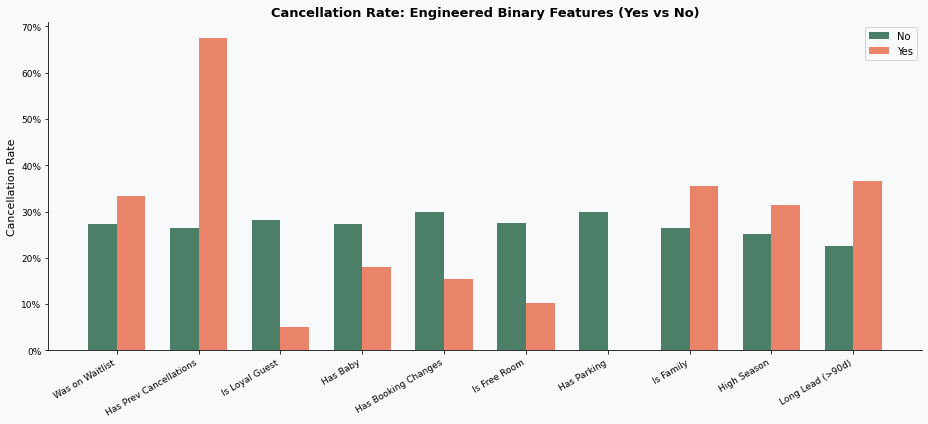

In [171]:


# ============================================================
# 16. ENGINEERED FEATURES vs CANCELLATION RATE  (summary bar)
# ============================================================
binary_features = {
    'Was on Waitlist':       'was_on_waiting_list',
    'Has Prev Cancellations':'has_prev_cancellations',
    'Is Loyal Guest':        'is_loyal_guest',
    'Has Baby':              'has_baby',
    'Has Booking Changes':   'has_booking_changes',
    'Is Free Room':          'is_free_room',
    'Has Parking':           'has_parking',
    'Is Family':             'is_family',
    'High Season':           'is_high_season',
    'Long Lead (>90d)':      'is_long_lead',
}

rows = []
for label, col in binary_features.items():
    for flag, group in [(0, 'No'), (1, 'Yes')]:
        rate = df[df[col] == flag]['is_canceled'].mean()
        rows.append({'Feature': label, 'Group': group, 'Cancel Rate': rate})

feat_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(binary_features))
width = 0.35
labels = list(binary_features.keys())

no_vals  = feat_df[feat_df['Group']=='No']['Cancel Rate'].values
yes_vals = feat_df[feat_df['Group']=='Yes']['Cancel Rate'].values

ax.bar(x - width/2, no_vals,  width, label='No',  color=C_KEEP,   alpha=0.85)
ax.bar(x + width/2, yes_vals, width, label='Yes', color=C_CANCEL, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Cancellation Rate')
ax.set_title('Cancellation Rate: Engineered Binary Features (Yes vs No)')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

In [176]:
def check_cardinality(df, categorical_columns=None):
    """
    Identify high cardinality features in a DataFrame
    """
    if categorical_columns is None:
        # Automatically detect categorical columns
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    cardinality_report = []
    
    for col in categorical_columns:
        unique_count = df[col].nunique()
        cardinality_report.append({
            'Feature': col,
            'Unique_Count': unique_count,
            'Cardinality_Level': 'Very High' if unique_count > 100 else 
                                'High' if unique_count > 50 else 
                                'Medium' if unique_count > 10 else 'Low',
            'Most_Frequent_Value': df[col].mode().iloc[0] if len(df[col].mode()) > 0 else None,
            'Freq_of_Top_Value': (df[col].value_counts().iloc[0] / len(df)) * 100
        })
    
    report_df = pd.DataFrame(cardinality_report)
    return report_df.sort_values('Unique_Count', ascending=False)

# Example usage:
cardinality_df = check_cardinality(df)
cardinality_df

,Feature,Unique_Count,Cardinality_Level,Most_Frequent_Value,Freq_of_Top_Value
2,country,177,Very High,PRT,31.804556
7,arrival_date_month_name,12,Medium,August,12.893147
3,market_segment,7,Low,Online TA,59.085040
5,reserved_room_type,7,Low,A,64.802389
1,meal,5,Low,BB,77.808522
4,distribution_channel,5,Low,TA/TO,79.092880
8,lead_bucket,5,Low,31–90d,26.033020
6,customer_type,4,Low,Transient,82.530898
9,season,4,Low,Summer,33.316039
0,hotel,2,Low,City Hotel,60.952776


### 5. Handle Imbalance and Modeling

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, f1_score, 
                             precision_recall_curve, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import numpy as np

In [194]:
# --- 1. Separate features and target

# Drop visualization helper columns before modeling
viz_cols = ['arrival_date_month_name', 'lead_bucket', 'season', 'total_revenue']
df = df.drop(columns=[c for c in viz_cols if c in df.columns])

X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

# --- 2. Train / Val / Test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train target: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: (60715, 35), Val: (13010, 35), Test: (13011, 35)
Train target: {0: 0.727, 1: 0.273}


In [195]:
# --- 3. Group rare countries (train-only, apply to val/test)
def group_rare_categories(train, val, test, col, top_n=20):
    train, val, test = train.copy(), val.copy(), test.copy()
    for df_ in [train, val, test]:
        df_[col] = df_[col].astype(str)
    top_vals = train[col].value_counts().nlargest(top_n).index
    for df_ in [train, val, test]:
        df_[col] = df_[col].where(df_[col].isin(top_vals), 'Other')
    return train, val, test

X_train, X_val, X_test = group_rare_categories(
    X_train, X_val, X_test, col='country', top_n=20
)

In [196]:
def check_cardinality(df, categorical_columns=None):
    """
    Identify high cardinality features in a DataFrame
    """
    if categorical_columns is None:
        # Automatically detect categorical columns
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    cardinality_report = []
    
    for col in categorical_columns:
        unique_count = df[col].nunique()
        cardinality_report.append({
            'Feature': col,
            'Unique_Count': unique_count,
            'Cardinality_Level': 'Very High' if unique_count > 100 else 
                                'High' if unique_count > 50 else 
                                'Medium' if unique_count > 10 else 'Low',
            'Most_Frequent_Value': df[col].mode().iloc[0] if len(df[col].mode()) > 0 else None,
            'Freq_of_Top_Value': (df[col].value_counts().iloc[0] / len(df)) * 100
        })
    
    report_df = pd.DataFrame(cardinality_report)
    return report_df.sort_values('Unique_Count', ascending=False)

# Example usage:
cardinality_df = check_cardinality(df)
cardinality_df

,Feature,Unique_Count,Cardinality_Level,Most_Frequent_Value,Freq_of_Top_Value
2,country,177,Very High,PRT,31.804556
3,market_segment,7,Low,Online TA,59.085040
5,reserved_room_type,7,Low,A,64.802389
1,meal,5,Low,BB,77.808522
4,distribution_channel,5,Low,TA/TO,79.092880
6,customer_type,4,Low,Transient,82.530898
0,hotel,2,Low,City Hotel,60.952776


In [197]:
# --- 4. Identify column types
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'customer_type']
Numerical: ['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'adr', 'total_of_special_requests', 'has_agent', 'arrival_month', 'arrival_weekday', 'was_on_waiting_list', 'has_prev_cancellations', 'is_loyal_guest', 'has_baby', 'cancel_rate_history', 'has_booking_changes', 'is_free_room', 'has_parking', 'total_nights', 'total_guests', 'is_family', 'is_high_season', 'is_long_lead']


In [198]:
# --- 5. Preprocessor (for Logistic Regression)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

<Axes: >

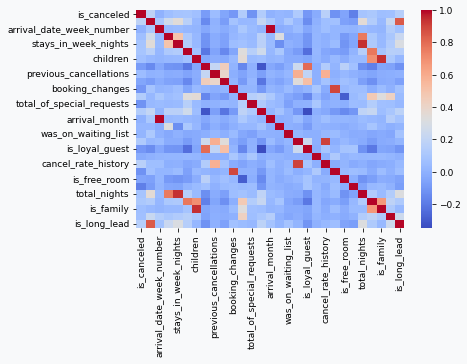

In [199]:
sns.heatmap(df.corr(), cmap='coolwarm')

In [200]:
# --- 6. Class imbalance ratio
neg, pos = np.bincount(y_train)
class_ratio = neg / pos
print(f"Class ratio (neg/pos): {class_ratio:.2f}")

Class ratio (neg/pos): 2.67


In [201]:
# --- 7. Threshold tuning function
def best_threshold(model, X_tr, y_tr, X_val, y_val, 
                   min_recall=0.75, cat_features=None):
    if cat_features is not None:
        model.fit(X_tr, y_tr, cat_features=cat_features)
    else:
        model.fit(X_tr, y_tr)
    
    y_prob = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
    f1 = 2*(precision[:-1]*recall[:-1]) / (precision[:-1]+recall[:-1]+1e-9)
    
    df_thr = pd.DataFrame({
        'threshold': thresholds,
        'precision': precision[:-1],
        'recall': recall[:-1],
        'f1': f1
    })
    
    valid = df_thr[df_thr['recall'] >= min_recall]
    best = valid.sort_values('f1', ascending=False).iloc[0]
    return model, y_prob, best

In [202]:
# --- 8. CatBoost categorical column indices
cat_cols_idx = [X_train.columns.get_loc(c) for c in cat_cols]

# --- 9. Define models
models = {
    'Logistic': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        scale_pos_weight=class_ratio, random_state=42, verbose=-1
    ),
    'LightGBM_Tuned': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=class_ratio,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        loss_function='Logloss', eval_metric='F1',
        class_weights=[1, class_ratio],
        random_state=42, verbose=0
    ),
}

In [203]:
# --- 10. Train and evaluate all models on validation set
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == 'CatBoost':
        fitted_model, y_prob, best = best_threshold(
            model, X_train, y_train, X_val, y_val,
            min_recall=0.70,  # ← lowered from 0.75
            cat_features=cat_cols_idx
        )
    else:
        fitted_model, y_prob, best = best_threshold(
            model, X_train_enc, y_train, X_val_enc, y_val,
            min_recall=0.70   # ← lowered from 0.75
        )
    results[name] = best
    print(f"  threshold={best['threshold']:.3f}, "
          f"precision={best['precision']:.3f}, "
          f"recall={best['recall']:.3f}, "
          f"f1={best['f1']:.3f}")

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
print("\nModel Comparison (Validation):")
print(results_df)

Training Logistic...
  threshold=0.561, precision=0.560, recall=0.711, f1=0.627
Training LightGBM...
  threshold=0.581, precision=0.639, recall=0.763, f1=0.695
Training LightGBM_Tuned...
  threshold=0.505, precision=0.598, recall=0.826, f1=0.694
Training CatBoost...
  threshold=0.553, precision=0.619, recall=0.784, f1=0.692

Model Comparison (Validation):
                threshold  precision    recall        f1
LightGBM         0.580524   0.638895  0.762750  0.695351
LightGBM_Tuned   0.505043   0.597959  0.825585  0.693573
CatBoost         0.552894   0.619408  0.784165  0.692116
Logistic         0.560585   0.560240  0.711468  0.626862


In [204]:
# --- 11. Final evaluation on test set with best model
best_name = results_df.index[0]
best_thr  = results_df.loc[best_name, 'threshold']
best_model = models[best_name]

print(f"\nBest model: {best_name} | Threshold: {best_thr:.3f}")

from scipy.sparse import vstack

if best_name == 'CatBoost':
    X_full = pd.concat([X_train, X_val])
    y_full = pd.concat([y_train, y_val])
    best_model.fit(X_full, y_full, cat_features=cat_cols_idx)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
else:
    X_full_enc = vstack([X_train_enc, X_val_enc])
    y_full = pd.concat([y_train, y_val])
    best_model.fit(X_full_enc, y_full)
    y_test_prob = best_model.predict_proba(X_test_enc)[:, 1]

y_test_pred = (y_test_prob >= best_thr).astype(int)

print("\n===== TEST SET RESULTS =====")
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")


Best model: LightGBM | Threshold: 0.581

===== TEST SET RESULTS =====
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      9461
           1       0.64      0.76      0.69      3550

    accuracy                           0.82     13011
   macro avg       0.77      0.80      0.78     13011
weighted avg       0.83      0.82      0.82     13011

ROC-AUC: 0.8939


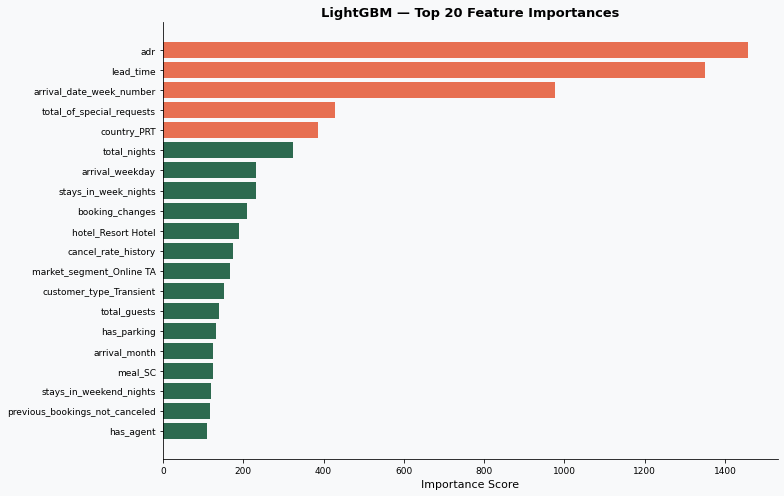

In [206]:

# ============================================================
# 17. FEATURE IMPORTANCE  (from trained LightGBM)
# ============================================================
# Run this AFTER training — requires best_model and feat_names to exist

feat_imp_plot = feat_imp.head(20)   # feat_imp from cell 12 in modeling section

fig, ax = plt.subplots(figsize=(11, 7))
colors = [C_CANCEL if i < 5 else C_KEEP for i in range(len(feat_imp_plot))]
ax.barh(feat_imp_plot['feature'][::-1],
        feat_imp_plot['importance'][::-1],
        color=colors[::-1])
ax.set_title(f'{best_name} — Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


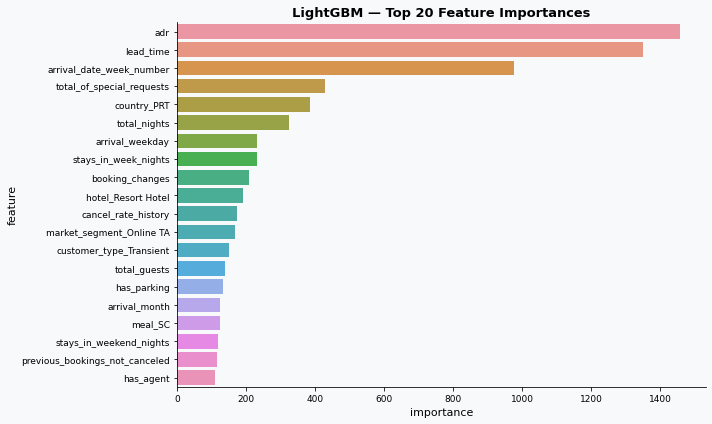

In [205]:
# --- 12. Feature importance
if best_name in ['CatBoost', 'LightGBM', 'LightGBM_Tuned']:
    
    if best_name == 'CatBoost':
        feat_names = list(X_train.columns)
    else:
        feat_names = num_cols + list(
            preprocessor.named_transformers_['cat']
            .get_feature_names_out(cat_cols)
        )
    
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': feat_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='importance', y='feature')
    plt.title(f'{best_name} — Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()

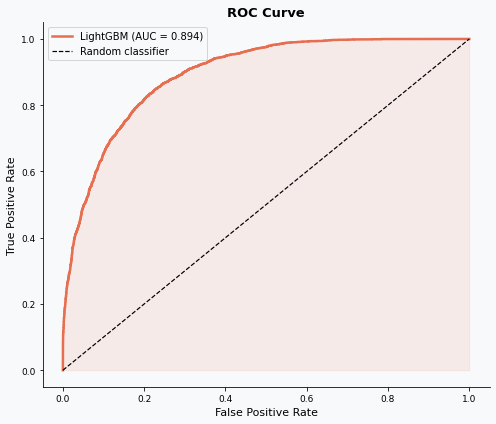

In [207]:

# ============================================================
# 18. ROC CURVE
# ============================================================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_score   = roc_auc_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=C_CANCEL, linewidth=2.5,
        label=f'LightGBM (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1.2, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color=C_CANCEL)
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

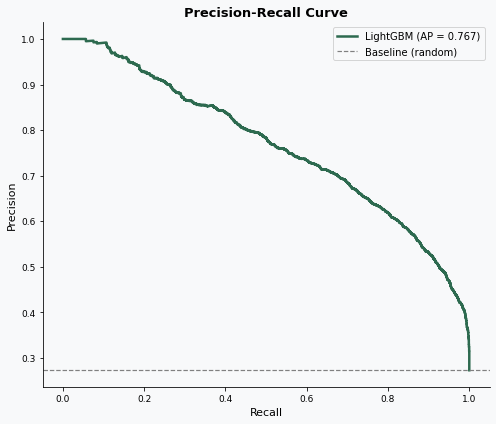

In [208]:

# ============================================================
# 19. PRECISION-RECALL CURVE
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_vals, precision_vals, color=C_KEEP, linewidth=2.5,
        label=f'LightGBM (AP = {ap:.3f})')
ax.axhline(df['is_canceled'].mean(), color='gray', linestyle='--',
           linewidth=1.2, label='Baseline (random)')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout()
plt.show()



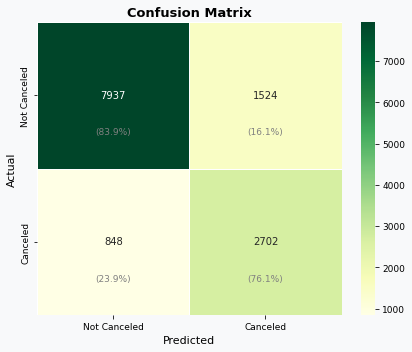

In [209]:
# ============================================================
# 20. CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=['Not Canceled','Canceled'],
            yticklabels=['Not Canceled','Canceled'],
            linewidths=1, linecolor='white', ax=ax)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.75, f'({cm_pct[i,j]:.1%})',
                ha='center', va='center',
                fontsize=9, color='gray')

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [210]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data (never val or test)
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_enc, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE:  {np.bincount(y_train_sm)}")

# Train LightGBM on SMOTE data (no scale_pos_weight needed now)
lgbm_smote = LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    random_state=42, verbose=-1
)

_, y_prob_sm, best_sm = best_threshold(
    lgbm_smote, X_train_sm, y_train_sm, X_val_enc, y_val,
    min_recall=0.70
)

print(f"\nLightGBM + SMOTE:")
print(f"threshold={best_sm['threshold']:.3f}, "
      f"precision={best_sm['precision']:.3f}, "
      f"recall={best_sm['recall']:.3f}, "
      f"f1={best_sm['f1']:.3f}")

Before SMOTE: [44152 16563]
After SMOTE:  [44152 44152]

LightGBM + SMOTE:
threshold=0.355, precision=0.613, recall=0.790, f1=0.690
